1) make sure to clear your dataset cache
2) if you run this multiple times, you should clear the existing output json files first
3) run the script below to count tokens:
```bash
!bash .scripts/count_tokens.sh
```

3442


/tmp/ipykernel_2334664/864868886.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats = df.groupby(["lang", "schema_label"]).apply(aggregate).reset_index()


,mean_tokens,mean_trunc_tokens,trunc_ratio
lang,,,
sparql,188.943057,18.377385,0.062178
sql,168.408913,13.212818,0.049334
cypher,253.653112,42.687882,0.111124


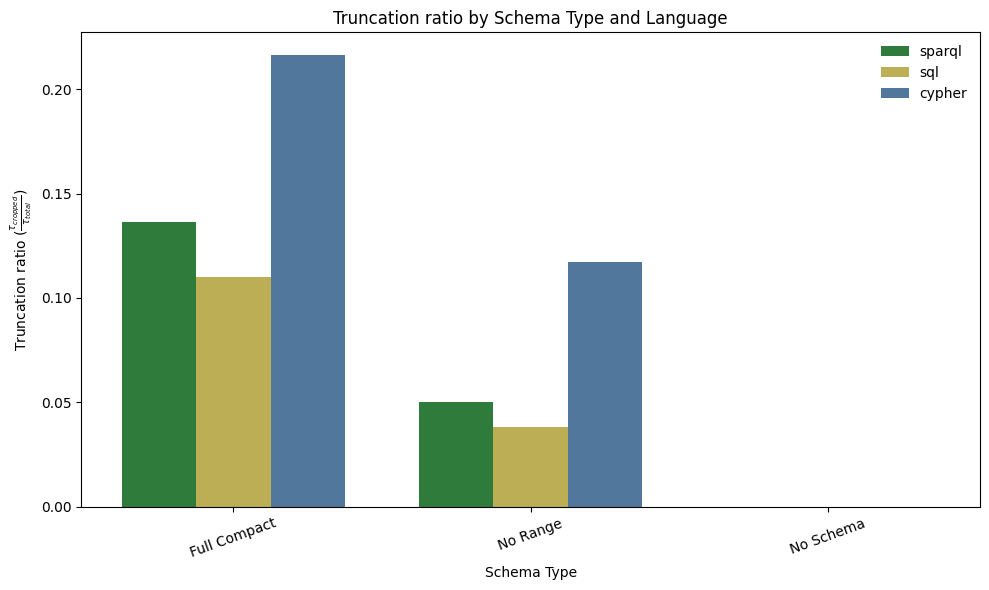

schema_label,Full Compact,No Range,No Schema
lang,,,
sparql,0.136593,0.049941,0.0
sql,0.109787,0.038213,0.0
cypher,0.216400,0.116973,0.0


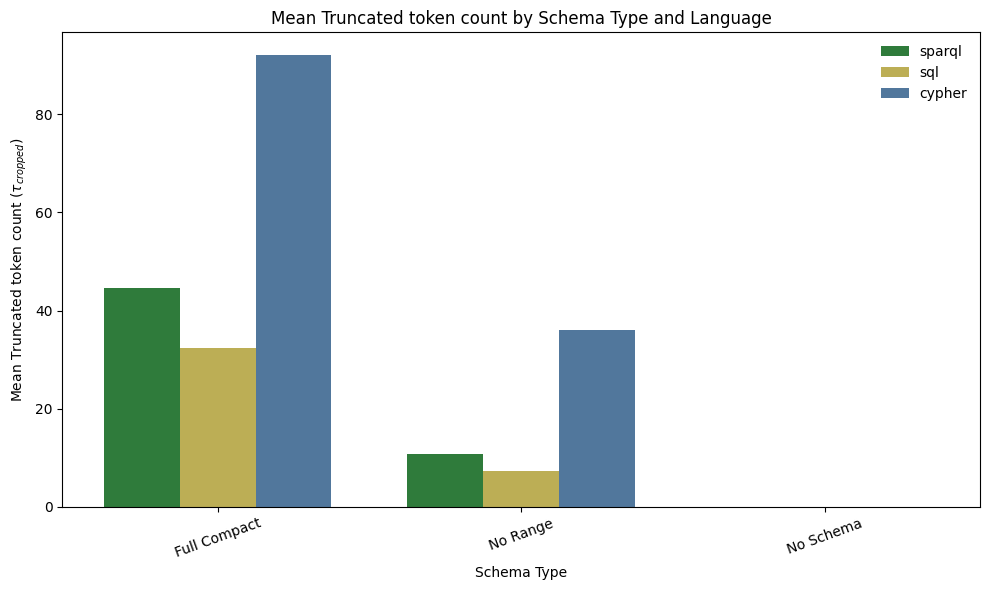

schema_label,Full Compact,No Range,No Schema
lang,,,
sparql,44.492155,10.640000,0.0
sql,32.408177,7.230276,0.0
cypher,92.136796,35.926851,0.0


In [10]:
# analysis.ipynb
import json
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------
# 1. Load all jsonl
# -----------------
base_dir = pathlib.Path("results/counts/")
records = []
for l_dir in base_dir.iterdir():
    if not l_dir.is_dir():
        continue
    lang = l_dir.name.lower()
    for schema_dir in l_dir.iterdir():
        if not schema_dir.is_dir():
            continue
        schema_type = schema_dir.name
        for file in schema_dir.glob("*.jsonl"):
            with file.open("r", encoding="utf-8") as f:
                for line in f:
                    rec = json.loads(line)
                    rec["lang"] = lang
                    rec["schema"] = schema_type
                    records.append(rec)

df = pd.DataFrame(records)
print(len(df[df["truncated_tokens"] > 0]))

# -----------------
# 2. Rename schema types for readability
# -----------------
schema_labels = {
    "compact": "Full Compact",
    "norange": "No Range",
    "peteshaw": "No Range",
    "none": "No Schema"
}
df["schema_label"] = df["schema"].map(schema_labels).fillna(df["schema"])

# -----------------
# 3. Aggregate stats
# -----------------
def aggregate(group):
    total_tokens = group["token_count"].sum()
    total_trunc_tokens = group["truncated_tokens"].sum()
    return pd.Series({
        "mean_tokens": total_tokens / len(group),
        "mean_trunc_tokens": total_trunc_tokens / len(group),
        "trunc_ratio": total_trunc_tokens / total_tokens if total_tokens > 0 else 0,
    })

stats = df.groupby(["lang", "schema_label"]).apply(aggregate).reset_index()

# -----------------
# 4. Language summary table
# -----------------
lang_table = stats.groupby("lang").agg({
    "mean_tokens": "mean",
    "mean_trunc_tokens": "mean",
    "trunc_ratio": "mean"  # mean across schema types
})
lang_table = lang_table.loc[["sparql", "sql", "cypher"]]  # enforce ordering
display(lang_table)

# -----------------
# 5. Pivot for trunc ratio (schema rows, lang cols)
# -----------------
pivot_trunc = stats.pivot(index="schema_label", columns="lang", values="trunc_ratio")

languages = ["sparql", "sql", "cypher"]
colors = {
    "sparql": "#2F7B3B",
    "sql": "#BCAE55",
    "cypher": "#51779C",
}

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
index = np.arange(len(pivot_trunc.index))

for i, lang in enumerate(languages):
    ax.bar(index + i*bar_width,
           pivot_trunc[lang].values,
           bar_width,
           label=lang,
           color=colors[lang])

ax.set_xlabel("Schema Type")
ax.set_ylabel(r"Truncation ratio ($\frac{\tau_{cropped}}{\tau_{total}}$)")
ax.set_title("Truncation ratio by Schema Type and Language")
ax.set_xticks(index + bar_width)
ax.set_xticklabels(pivot_trunc.index, rotation=20)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(base_dir.joinpath("trunc_ratios.png"), dpi=300)
plt.savefig(base_dir.joinpath("trunc_ratios.svg"))
plt.savefig(base_dir.joinpath("trunc_ratios.pdf"))
plt.show()

pivot_trunc = pivot_trunc.loc[:, languages]  # enforce column order
pivot_trunc = pivot_trunc.T  # languages as rows
pivot_trunc = pivot_trunc.loc[["sparql", "sql", "cypher"]]  # enforce row order
display(pivot_trunc)

# -----------------
# 6. Pivot for mean trunc token length (schema rows, lang cols)
# -----------------
pivot_mean_token_trunc = stats.pivot(index="schema_label", columns="lang", values="mean_trunc_tokens")

languages = ["sparql", "sql", "cypher"]
colors = {
    "sparql": "#2F7B3B",
    "sql": "#BCAE55",
    "cypher": "#51779C",
}

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
index = np.arange(len(pivot_mean_token_trunc.index))

for i, lang in enumerate(languages):
    ax.bar(index + i*bar_width,
           pivot_mean_token_trunc[lang].values,
           bar_width,
           label=lang,
           color=colors[lang])

ax.set_xlabel("Schema Type")
ax.set_ylabel(r"Mean Truncated token count ($\tau_{cropped}$)")
ax.set_title("Mean Truncated token count by Schema Type and Language")
ax.set_xticks(index + bar_width)
ax.set_xticklabels(pivot_mean_token_trunc.index, rotation=20)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(base_dir.joinpath("trunc_token_counts.png"), dpi=300)
plt.savefig(base_dir.joinpath("trunc_token_counts.svg"))
plt.savefig(base_dir.joinpath("trunc_token_counts.pdf"))
plt.show()

pivot_mean_token_trunc = pivot_mean_token_trunc.loc[:, languages]  # enforce column order
pivot_mean_token_trunc = pivot_mean_token_trunc.T  # languages as rows
pivot_mean_token_trunc = pivot_mean_token_trunc.loc[["sparql", "sql", "cypher"]]  # enforce row order
display(pivot_mean_token_trunc)


In [11]:
# -----------------
# 7. Token length and truncation distribution
# -----------------

# Compute per-sample truncation ratio
df["trunc_ratio_sample"] = df["truncated_tokens"] / df["token_count"]
# print(df[df["truncated_tokens"] > 0]["trunc_ratio_sample"])
# print(len(df[df["truncated_tokens"] > 0]))
# print(len(df))

# Drop NaNs that may result from 0 token_count
df = df.dropna(subset=["trunc_ratio_sample"])

print(len(df))


40725


,lang,schema_label,mean_token_len,std_token_len,var_token_len,mean_trunc_ratio,std_trunc_ratio,var_trunc_ratio
0,cypher,Full Compact,425.770387,387.788761,150380.122996,0.085305,0.167268,0.027979
1,cypher,No Range,307.137459,280.765832,78829.452365,0.032374,0.108261,0.011721
2,cypher,No Schema,28.051492,6.034329,36.413131,0.000000,0.000000,0.000000
3,sparql,Full Compact,325.727956,282.096558,79578.468195,0.043880,0.121196,0.014688
4,sparql,No Range,213.049724,176.809525,31261.608270,0.009209,0.065728,0.004320
5,sparql,No Schema,28.051492,6.034329,36.413131,0.000000,0.000000,0.000000
6,sql,Full Compact,295.191160,255.676939,65370.697092,0.031752,0.106007,0.011237
7,sql,No Range,189.207735,155.826918,24282.028455,0.006290,0.053088,0.002818
8,sql,No Schema,20.827845,5.506505,30.321594,0.000000,0.000000,0.000000


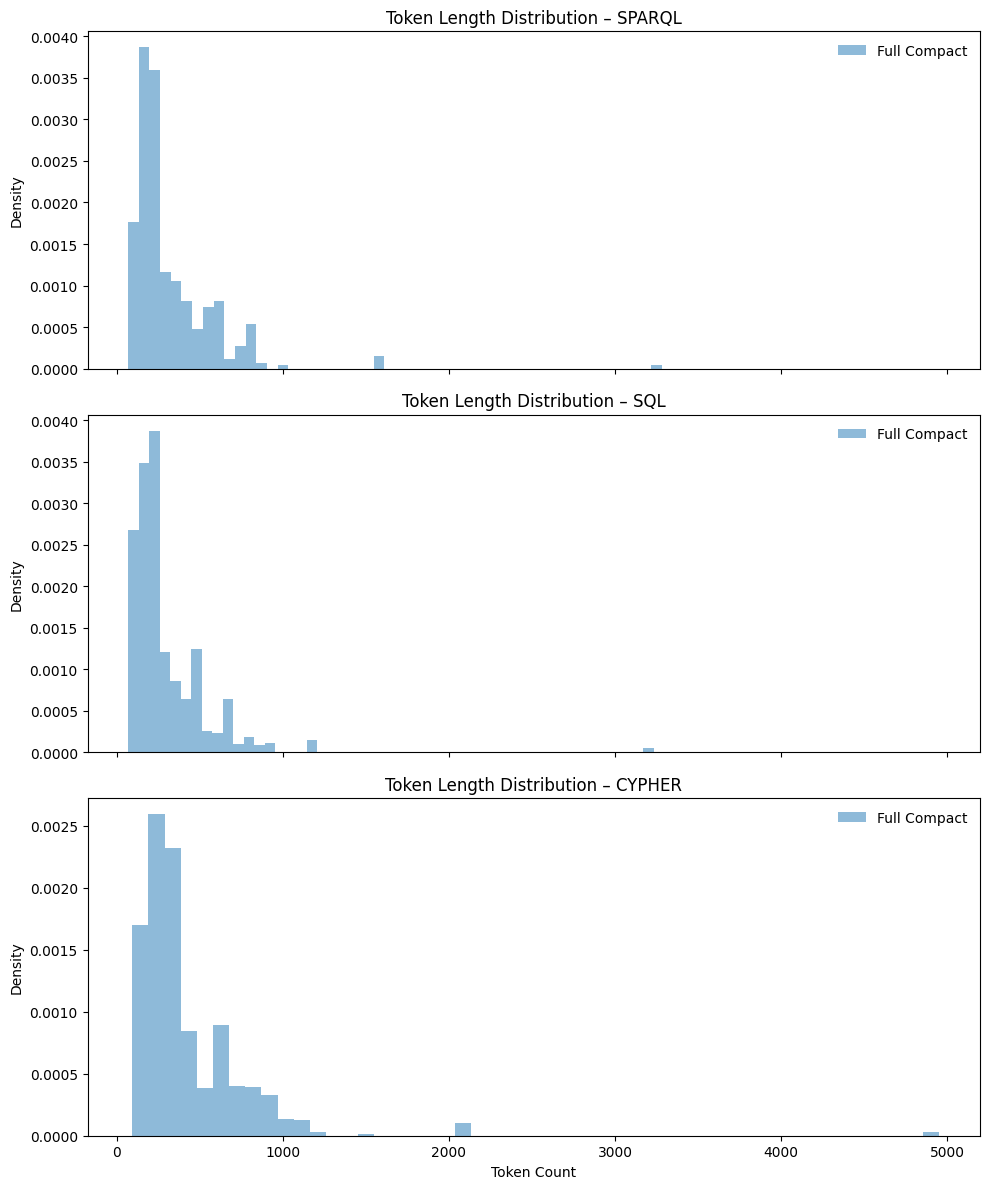

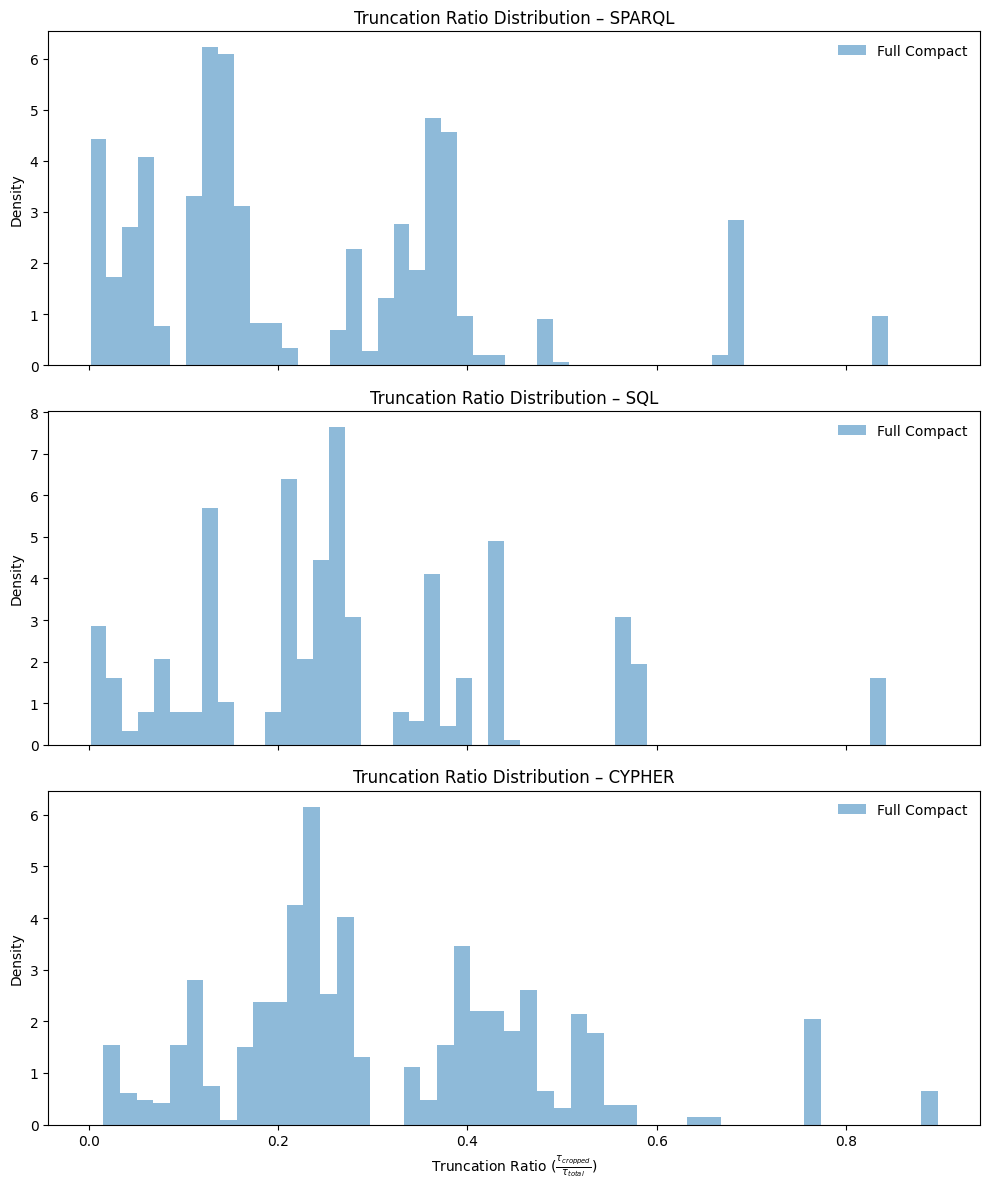

,lang,schema_label,Q1,Q3,IQR,Lower_Whisker,Upper_Whisker,Outlier_Count,Outlier_Percentage,Sample_Size
0,cypher,Full Compact,211.0,568.0,357.0,-324.5,1103.5,118,2.607735,4525
1,cypher,No Range,149.0,420.0,271.0,-257.5,826.5,78,1.723757,4525
2,cypher,No Schema,24.0,32.0,8.0,12.0,44.0,48,1.060773,4525
3,sparql,Full Compact,164.0,425.0,261.0,-227.5,816.5,150,3.314917,4525
4,sparql,No Range,108.0,280.0,172.0,-150.0,538.0,138,3.049724,4525
5,sparql,No Schema,24.0,32.0,8.0,12.0,44.0,48,1.060773,4525
6,sql,Full Compact,151.0,379.0,228.0,-191.0,721.0,168,3.712707,4525
7,sql,No Range,98.0,256.0,158.0,-139.0,493.0,128,2.828729,4525
8,sql,No Schema,17.0,24.0,7.0,6.5,34.5,87,1.922652,4525


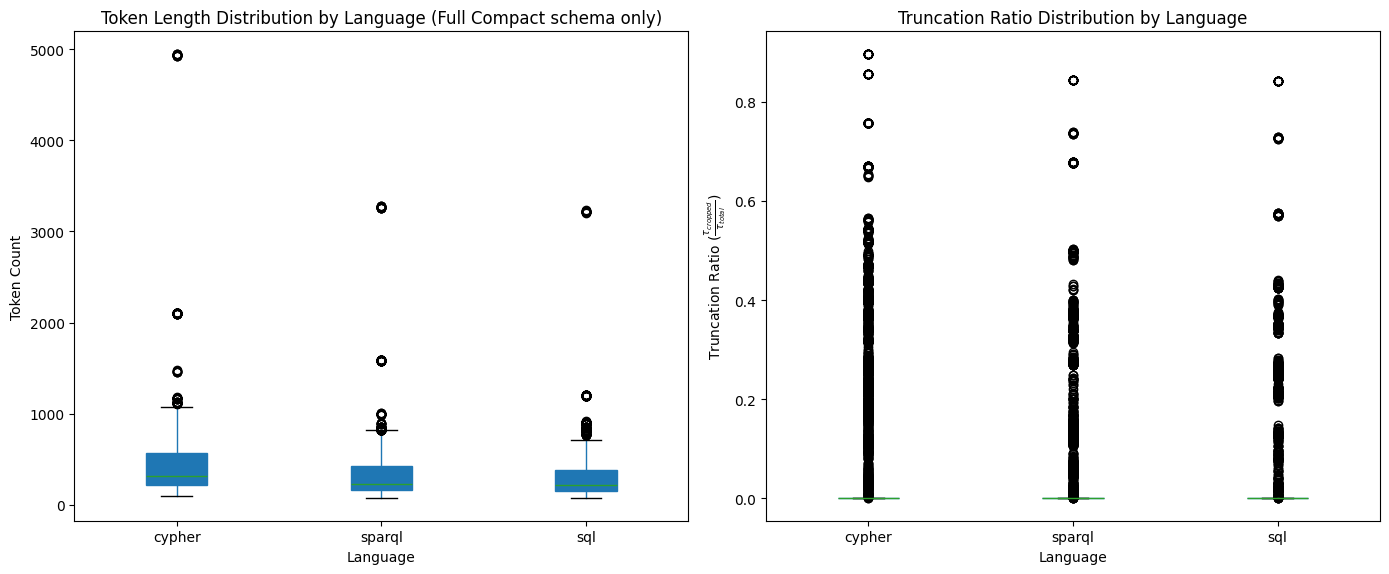

In [12]:
schemas = ["Full Compact"]  # df["schema_label"].unique()

# -----------------
# 7.1 Compute summary stats (mean, std, variance)
# -----------------
summary_stats = (
    df.groupby(["lang", "schema_label"])
    .agg(
        mean_token_len=("token_count", "mean"),
        std_token_len=("token_count", "std"),
        var_token_len=("token_count", "var"),
        mean_trunc_ratio=("trunc_ratio_sample", "mean"),
        std_trunc_ratio=("trunc_ratio_sample", "std"),
        var_trunc_ratio=("trunc_ratio_sample", "var"),
    )
    .reset_index()
)

display(summary_stats)

# Save stats
summary_stats.to_csv(base_dir.joinpath("token_trunc_distribution_stats.csv"), index=False)

# -----------------
# 7.2 Plot distribution of token lengths
# -----------------
fig, axes = plt.subplots(len(languages), 1, figsize=(10, 12), sharex=True)
for i, lang in enumerate(languages):
    subset = df[df["lang"] == lang]
    for schema in schemas:
        s = subset[subset["schema_label"] == schema]
        axes[i].hist(
            s["token_count"],
            bins=50,
            alpha=0.5,
            label=schema,
            density=True,
        )
    axes[i].set_title(f"Token Length Distribution – {lang.upper()}")
    axes[i].set_ylabel("Density")
    axes[i].legend(frameon=False)
axes[-1].set_xlabel("Token Count")
plt.tight_layout()
plt.savefig(base_dir.joinpath("token_length_distribution.png"), dpi=300)
plt.show()

# -----------------
# 7.3 Plot distribution of truncation ratio
# -----------------
fig, axes = plt.subplots(len(languages), 1, figsize=(10, 12), sharex=True)
for i, lang in enumerate(languages):
    subset = df[df["lang"] == lang]
    subset = subset[subset["truncated_tokens"] > 0]
    for schema in schemas:
        s = subset[subset["schema_label"] == schema]
        axes[i].hist(
            s["trunc_ratio_sample"],
            bins=50,
            alpha=0.5,
            label=schema,
            density=True,
        )
    axes[i].set_title(f"Truncation Ratio Distribution – {lang.upper()}")
    axes[i].set_ylabel("Density")
    axes[i].legend(frameon=False)
axes[-1].set_xlabel(r"Truncation Ratio ($\frac{\tau_{cropped}}{\tau_{total}}$)")
plt.tight_layout()
plt.savefig(base_dir.joinpath("truncation_ratio_distribution.png"), dpi=300)
plt.show()

# -----------------
# 7.3.5 Compute boxplot stats (IQR, whiskers, outliers) per language & schema
# -----------------
boxplot_stats = []

for (lang, schema), subset in df.groupby(["lang", "schema_label"]):
    q1 = subset["token_count"].quantile(0.25)
    q3 = subset["token_count"].quantile(0.75)
    iqr = q3 - q1

    # Define whiskers based on 1.5*IQR rule
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr

    # Outlier detection
    outliers = subset[
        (subset["token_count"] < lower_whisker) | (subset["token_count"] > upper_whisker)
    ]

    boxplot_stats.append({
        "lang": lang,
        "schema_label": schema,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Whisker": lower_whisker,
        "Upper_Whisker": upper_whisker,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": 100 * len(outliers) / len(subset),
        "Sample_Size": len(subset)
    })

boxplot_stats_df = pd.DataFrame(boxplot_stats)
display(boxplot_stats_df)

# Optional: save results
boxplot_stats_df.to_csv(base_dir.joinpath("boxplot_stats_by_schema.csv"), index=False)


# -----------------
# 7.4 Boxplots for variance visualization
# -----------------
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Token length boxplot
df[df["schema_label"] == "Full Compact"].boxplot(column="token_count", by="lang", ax=ax[0], grid=False, patch_artist=True)
# df.boxplot(column="token_count", by="lang", ax=ax[0], grid=False, patch_artist=True)
ax[0].set_title("Token Length Distribution by Language (Full Compact schema only)")
ax[0].set_xlabel("Language")
ax[0].set_ylabel("Token Count")

# Truncation ratio boxplot
df.boxplot(column="trunc_ratio_sample", by="lang", ax=ax[1], grid=False, patch_artist=True)
ax[1].set_title("Truncation Ratio Distribution by Language")
ax[1].set_xlabel("Language")
ax[1].set_ylabel(r"Truncation Ratio ($\frac{\tau_{cropped}}{\tau_{total}}$)")

plt.suptitle("")
plt.tight_layout()
plt.savefig(base_dir.joinpath("distribution_boxplots.png"), dpi=300)
plt.show()

In [4]:
# -----------------
# 7.3.5 Compute boxplot stats (IQR, whiskers, outliers)
# -----------------
boxplot_stats = []

for lang, subset in df.groupby("lang"):
    q1 = subset["token_count"].quantile(0.25)
    q3 = subset["token_count"].quantile(0.75)
    iqr = q3 - q1

    # Define whiskers based on 1.5*IQR rule
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr

    # Outlier detection
    outliers = subset[
        (subset["token_count"] < lower_whisker) | (subset["token_count"] > upper_whisker)
    ]

    boxplot_stats.append({
        "lang": lang,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Whisker": lower_whisker,
        "Upper_Whisker": upper_whisker,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": 100 * len(outliers) / len(subset)
    })

boxplot_stats_df = pd.DataFrame(boxplot_stats)
display(boxplot_stats_df)

# Optional: save to CSV
boxplot_stats_df.to_csv(base_dir.joinpath("boxplot_stats.csv"), index=False)

,lang,Q1,Q3,IQR,Lower_Whisker,Upper_Whisker,Outlier_Count,Outlier_Percentage
0,cypher,32.0,328.0,296.0,-412.0,772.0,649,4.780847
1,sparql,32.0,245.0,213.0,-287.5,564.5,750,5.524862
2,sql,24.0,223.0,199.0,-274.5,521.5,607,4.471455



### Truncation Count Distribution Summary (Outliers Removed) ###
Removed 1214 outliers from 40725 samples total.


/tmp/ipykernel_2334664/314864502.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: remove_outliers_iqr(g, "truncated_tokens"))


,lang,schema_label,mean_trunc_count,std_trunc_count,count
0,cypher,Full Compact,63.745124,136.229759,4461
1,cypher,No Range,8.674499,31.298014,4341
2,cypher,No Schema,0.000000,0.000000,4525
3,sparql,Full Compact,9.203040,30.145354,4211
4,sparql,No Range,0.000000,0.000000,4379
5,sparql,No Schema,0.000000,0.000000,4525
6,sql,Full Compact,1.627565,10.221949,4143
7,sql,No Range,0.000000,0.000000,4401
8,sql,No Schema,0.000000,0.000000,4525



### Mean Truncation Count (by Schema and Language, Outliers Removed) ###


lang,sparql,sql,cypher
schema_label,,,
Full Compact,9.20304,1.627565,63.745124
No Range,0.00000,0.000000,8.674499
No Schema,0.00000,0.000000,0.000000



### Std Dev of Truncation Count (by Schema and Language, Outliers Removed) ###


lang,sparql,sql,cypher
schema_label,,,
Full Compact,30.145354,10.221949,136.229759
No Range,0.000000,0.000000,31.298014
No Schema,0.000000,0.000000,0.000000


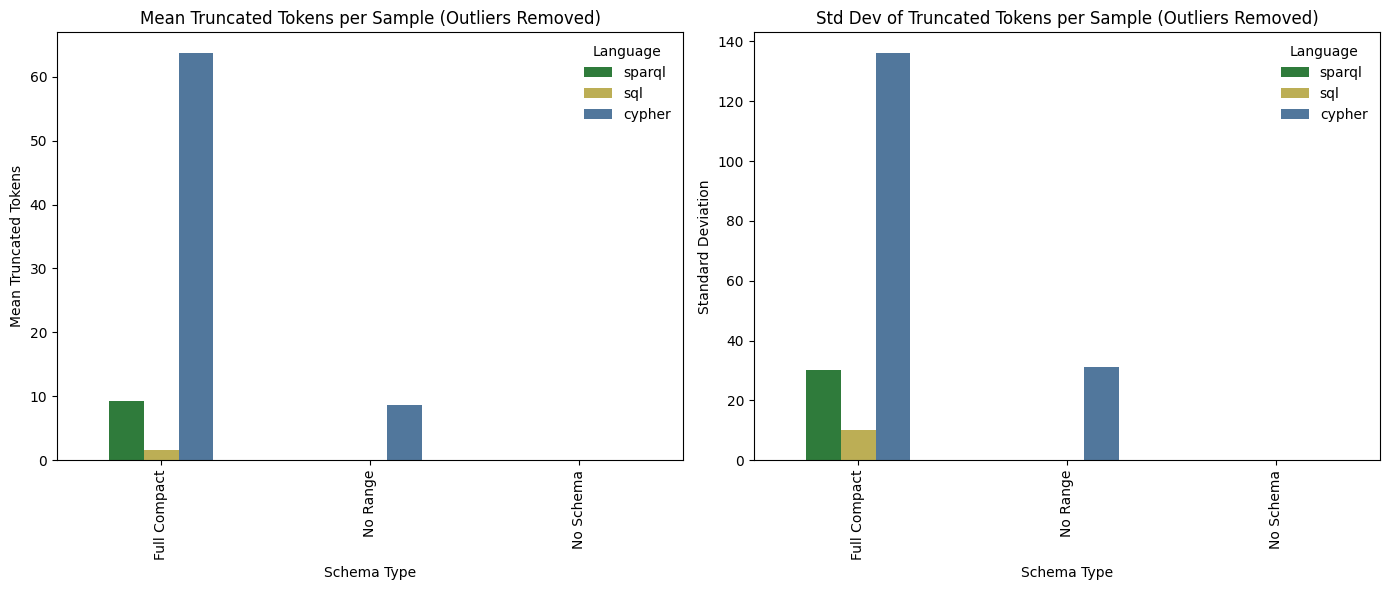

In [5]:
# -----------------
# 7.5 Truncation Count Distribution Analysis (with outlier removal)
# -----------------
print("\n### Truncation Count Distribution Summary (Outliers Removed) ###")

def remove_outliers_iqr(group, column):
    """Remove outliers from a DataFrame group using IQR."""
    Q1 = group[column].quantile(0.1)
    Q3 = group[column].quantile(0.9)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group[column] >= lower) & (group[column] <= upper)]

# Apply outlier removal per (lang, schema_label)
df_filtered = (
    df.groupby(["lang", "schema_label"], group_keys=False)
      .apply(lambda g: remove_outliers_iqr(g, "truncated_tokens"))
)

print(f"Removed {len(df) - len(df_filtered)} outliers from {len(df)} samples total.")

# Compute mean and std after outlier removal
trunc_stats = (
    df_filtered.groupby(["lang", "schema_label"])
    .agg(
        mean_trunc_count=("truncated_tokens", "mean"),
        std_trunc_count=("truncated_tokens", "std"),
        count=("truncated_tokens", "size")
    )
    .reset_index()
)

display(trunc_stats)

# Pivot tables for mean and std
pivot_mean_trunc = trunc_stats.pivot(index="schema_label", columns="lang", values="mean_trunc_count")
pivot_std_trunc = trunc_stats.pivot(index="schema_label", columns="lang", values="std_trunc_count")

# Enforce consistent order
pivot_mean_trunc = pivot_mean_trunc.loc[:, languages]
pivot_std_trunc = pivot_std_trunc.loc[:, languages]

print("\n### Mean Truncation Count (by Schema and Language, Outliers Removed) ###")
display(pivot_mean_trunc)

print("\n### Std Dev of Truncation Count (by Schema and Language, Outliers Removed) ###")
display(pivot_std_trunc)

# Save to CSV
pivot_mean_trunc.to_csv(base_dir.joinpath("trunc_count_mean_pivot_clean.csv"))
pivot_std_trunc.to_csv(base_dir.joinpath("trunc_count_std_pivot_clean.csv"))

# -----------------
# 7.6 Optional: Visualize mean and std of truncation counts
# -----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mean bar plot
pivot_mean_trunc.plot.bar(ax=axes[0], color=[colors.get(lang, "#999999") for lang in pivot_mean_trunc.columns])
axes[0].set_title("Mean Truncated Tokens per Sample (Outliers Removed)")
axes[0].set_xlabel("Schema Type")
axes[0].set_ylabel("Mean Truncated Tokens")
axes[0].legend(title="Language", frameon=False)

# Std bar plot
pivot_std_trunc.plot.bar(ax=axes[1], color=[colors.get(lang, "#999999") for lang in pivot_std_trunc.columns])
axes[1].set_title("Std Dev of Truncated Tokens per Sample (Outliers Removed)")
axes[1].set_xlabel("Schema Type")
axes[1].set_ylabel("Standard Deviation")
axes[1].legend(title="Language", frameon=False)

plt.tight_layout()
plt.savefig(base_dir.joinpath("truncation_count_summary_clean.png"), dpi=300)
plt.show()

# Token count examples

In [8]:
input_sql = "(sql) Count the number of stores the chain South has. | department_store | addresses : address_id (number) , address_details (text) | staff : staff_id (number) , staff_gender (text) , staff_name (text) | suppliers : supplier_id (number) , supplier_name (text) , supplier_phone (text) | department_store_chain : dept_store_chain_id (number) , dept_store_chain_name (text) | customers : customer_id (number) , payment_method_code (text) , customer_code (text) , customer_name (text) , customer_address (text) , customer_phone (text) , customer_email (text) | products : product_id (number) , product_type_code (text) , product_name (text) , product_price (number) | supplier_addresses : supplier_id (supplier_id) , address_id (address_id) , date_from (time) , date_to (time) | customer_addresses : customer_id (customer_id) , address_id (address_id) , date_from (time) , date_to (time) | customer_orders : order_id (number) , customer_id (customer_id) , order_status_code (text) , order_date (time) | department_stores : dept_store_id (number) , dept_store_chain_id (dept_store_chain_id) , store_name (text) , store_address (text) , store_phone (text) , store_email (text) | departments : department_id (number) , dept_store_id (dept_store_id) , department_name (text) | order_items : order_item_id (number) , order_id (order_id) , product_id (product_id) | product_suppliers : product_id (product_id) , supplier_id (supplier_id) , date_supplied_from (time) , date_supplied_to (time) , total_amount_purchased (text) , total_value_purchased (number) | staff_department_assignments : staff_id (staff_id) , department_id (department_id) , date_assigned_from (time) , job_title_code (text) , date_assigned_to (time)"
input_sparql = "(sparql) Count the number of stores the chain South has. | department_store | customer_orders: order_status_code (string) , order_id (integer) , order_date (dateTime) , customer_id (integer) , CUSTOMER_ID (customers) | department_store_chain: dept_store_chain_name (string) , dept_store_chain_id (integer) | departments: dept_store_id (integer) , department_name (string) , department_id (integer) , DEPT_STORE_ID (department_stores) | staff_department_assignments: staff_id (integer) , job_title_code (string) , department_id (integer) , date_assigned_to (dateTime) , date_assigned_from (dateTime) , STAFF_ID (staff) , DEPARTMENT_ID (departments) | supplier_addresses: supplier_id (integer) , date_to (dateTime) , date_from (dateTime) , address_id (integer) , SUPPLIER_ID (suppliers) , ADDRESS_ID (addresses) | suppliers: supplier_phone (string) , supplier_name (string) , supplier_id (integer) | department_stores: store_phone (string) , store_name (string) , store_email (string) , store_address (string) , dept_store_id (integer) , dept_store_chain_id (integer) , DEPT_STORE_CHAIN_ID (department_store_chain) | staff: staff_name (string) , staff_id (integer) , staff_gender (string) | customers: payment_method_code (string) , customer_phone (string) , customer_name (string) , customer_id (integer) , customer_email (string) , customer_code (string) , customer_address (string) | customer_addresses: date_to (dateTime) , date_from (dateTime) , customer_id (integer) , address_id (integer) , CUSTOMER_ID (customers) , ADDRESS_ID (addresses) | product_suppliers: total_value_purchased (decimal) , total_amount_purchased (string) , supplier_id (integer) , product_id (integer) , date_supplied_to (dateTime) , date_supplied_from (dateTime) , SUPPLIER_ID (suppliers) , PRODUCT_ID (products) | products: product_type_code (string) , product_price (decimal) , product_name (string) , product_id (integer) | order_items: product_id (integer) , order_item_id (integer) , order_id (integer) , PRODUCT_ID (products) , ORDER_ID (customer_orders) | addresses: address_id (integer) , address_details (string)"

input_cypher_full_mapping_strategy_none = "(cypher) Count the number of stores the chain South has. | department_store | ROOT__addresses: uri (String) , addresses__address_id (Long) , addresses__address_details (String) | ROOT__department_stores: uri (String) , department_stores__store_name (String) , department_stores__store_address (String) , department_stores__store_email (String) , department_stores__dept_store_id (Long) , department_stores__dept_store_chain_id (Long) , department_stores__store_phone (String) , department_stores__DEPT_STORE_CHAIN_ID (ROOT__department_store_chain) | ROOT__customers: uri (String) , customers__customer_address (String) , customers__payment_method_code (String) , customers__customer_email (String) , customers__customer_name (String) , customers__customer_code (String) , customers__customer_phone (String) , customers__customer_id (Long) | ROOT__suppliers: uri (String) , suppliers__supplier_id (Long) , suppliers__supplier_name (String) , suppliers__supplier_phone (String) | ROOT__departments: uri (String) , departments__dept_store_id (Long) , departments__department_id (Long) , departments__department_name (String) , departments__DEPT_STORE_ID (ROOT__department_stores) | ROOT__staff: uri (String) , staff__staff_gender (String) , staff__staff_id (Long) , staff__staff_name (String) | ROOT__order_items: uri (String) , order_items__product_id (Long) , order_items__order_id (Long) , order_items__order_item_id (Long) , order_items__ORDER_ID (ROOT__customer_orders) , order_items__PRODUCT_ID (ROOT__products) | ROOT__product_suppliers: uri (String) , product_suppliers__date_supplied_from (LocalDateTime) , product_suppliers__date_supplied_to (LocalDateTime) , product_suppliers__product_id (Long) , product_suppliers__total_value_purchased (Double) , product_suppliers__total_amount_purchased (String) , product_suppliers__supplier_id (Long) , product_suppliers__PRODUCT_ID (ROOT__products) , product_suppliers__SUPPLIER_ID (ROOT__suppliers) | ROOT__supplier_addresses: uri (String) , supplier_addresses__date_from (LocalDateTime) , supplier_addresses__address_id (Long) , supplier_addresses__date_to (LocalDateTime) , supplier_addresses__supplier_id (Long) , supplier_addresses__ADDRESS_ID (ROOT__addresses) , supplier_addresses__SUPPLIER_ID (ROOT__suppliers) | ROOT__customer_orders: uri (String) , customer_orders__order_status_code (String) , customer_orders__order_date (LocalDateTime) , customer_orders__customer_id (Long) , customer_orders__order_id (Long) , customer_orders__CUSTOMER_ID (ROOT__customers) | ROOT__department_store_chain: uri (String) , department_store_chain__dept_store_chain_name (String) , department_store_chain__dept_store_chain_id (Long) | ROOT__staff_department_assignments: uri (String) , staff_department_assignments__department_id (Long) , staff_department_assignments__job_title_code (String) , staff_department_assignments__date_assigned_from (LocalDateTime) , staff_department_assignments__date_assigned_to (LocalDateTime) , staff_department_assignments__staff_id (Long) , staff_department_assignments__DEPARTMENT_ID (ROOT__departments) , staff_department_assignments__STAFF_ID (ROOT__staff) | ROOT__products: uri (String) , products__product_id (Long) , products__product_name (String) , products__product_price (Double) , products__product_type_code (String) | ROOT__customer_addresses: uri (String) , customer_addresses__customer_id (Long) , customer_addresses__date_from (LocalDateTime) , customer_addresses__address_id (Long) , customer_addresses__date_to (LocalDateTime) , customer_addresses__ADDRESS_ID (ROOT__addresses) , customer_addresses__CUSTOMER_ID (ROOT__customers)" 
input_cypher_full_mapping_normalize = "(cypher) Count the number of stores the chain South has. | department_store | ROOT__addresses: addresses__address_id (int) , addresses__address_details (string) | ROOT__department_stores: department_stores__store_name (string) , department_stores__store_address (string) , department_stores__store_email (string) , department_stores__dept_store_id (int) , department_stores__store_phone (string) , department_stores__DEPT_STORE_CHAIN_ID (ROOT__department_store_chain) | ROOT__customers: customers__customer_address (string) , customers__payment_method_code (string) , customers__customer_email (string) , customers__customer_name (string) , customers__customer_code (string) , customers__customer_phone (string) , customers__customer_id (int) | ROOT__suppliers: suppliers__supplier_id (int) , suppliers__supplier_name (string) , suppliers__supplier_phone (string) | ROOT__departments: departments__department_id (int) , departments__department_name (string) , departments__DEPT_STORE_ID (ROOT__department_stores) | ROOT__staff: staff__staff_gender (string) , staff__staff_id (int) , staff__staff_name (string) | ROOT__order_items: order_items__order_item_id (int) , order_items__ORDER_ID (ROOT__customer_orders) , order_items__PRODUCT_ID (ROOT__products) | ROOT__product_suppliers: product_suppliers__date_supplied_from (date) , product_suppliers__date_supplied_to (date) , product_suppliers__total_value_purchased (Double) , product_suppliers__total_amount_purchased (string) , product_suppliers__PRODUCT_ID (ROOT__products) , product_suppliers__SUPPLIER_ID (ROOT__suppliers) | ROOT__supplier_addresses: supplier_addresses__date_from (date) , supplier_addresses__date_to (date) , supplier_addresses__ADDRESS_ID (ROOT__addresses) , supplier_addresses__SUPPLIER_ID (ROOT__suppliers) | ROOT__customer_orders: customer_orders__order_status_code (string) , customer_orders__order_date (date) , customer_orders__order_id (int) , customer_orders__CUSTOMER_ID (ROOT__customers) | ROOT__department_store_chain: department_store_chain__dept_store_chain_name (string) , department_store_chain__dept_store_chain_id (int) | ROOT__staff_department_assignments: staff_department_assignments__job_title_code (string) , staff_department_assignments__date_assigned_from (date) , staff_department_assignments__date_assigned_to (date) , staff_department_assignments__DEPARTMENT_ID (ROOT__departments) , staff_department_assignments__STAFF_ID (ROOT__staff) | ROOT__products: products__product_id (int) , products__product_name (string) , products__product_price (Double) , products__product_type_code (string) | ROOT__customer_addresses: customer_addresses__date_from (date) , customer_addresses__date_to (date) , customer_addresses__ADDRESS_ID (ROOT__addresses) , customer_addresses__CUSTOMER_ID (ROOT__customers)"
input_cypher_full_mapping_normalise = "(cypher) Count the number of stores the chain South has. | department_store | ROOT__addresses: addresses__address_id (int) , addresses__address_details (str) | ROOT__department_stores: department_stores__store_name (str) , department_stores__store_address (str) , department_stores__store_email (str) , department_stores__dept_store_id (int) , department_stores__store_phone (str) , department_stores__DEPT_STORE_CHAIN_ID (ROOT__department_store_chain) | ROOT__customers: customers__customer_address (str) , customers__payment_method_code (str) , customers__customer_email (str) , customers__customer_name (str) , customers__customer_code (str) , customers__customer_phone (str) , customers__customer_id (int) | ROOT__suppliers: suppliers__supplier_id (int) , suppliers__supplier_name (str) , suppliers__supplier_phone (str) | ROOT__departments: departments__department_id (int) , departments__department_name (str) , departments__DEPT_STORE_ID (ROOT__department_stores) | ROOT__staff: staff__staff_gender (str) , staff__staff_id (int) , staff__staff_name (str) | ROOT__order_items: order_items__order_item_id (int) , order_items__ORDER_ID (ROOT__customer_orders) , order_items__PRODUCT_ID (ROOT__products) | ROOT__product_suppliers: product_suppliers__date_supplied_from (date) , product_suppliers__date_supplied_to (date) , product_suppliers__total_value_purchased (Double) , product_suppliers__total_amount_purchased (str) , product_suppliers__PRODUCT_ID (ROOT__products) , product_suppliers__SUPPLIER_ID (ROOT__suppliers) | ROOT__supplier_addresses: supplier_addresses__date_from (date) , supplier_addresses__date_to (date) , supplier_addresses__ADDRESS_ID (ROOT__addresses) , supplier_addresses__SUPPLIER_ID (ROOT__suppliers) | ROOT__customer_orders: customer_orders__order_status_code (str) , customer_orders__order_date (date) , customer_orders__order_id (int) , customer_orders__CUSTOMER_ID (ROOT__customers) | ROOT__department_store_chain: department_store_chain__dept_store_chain_name (str) , department_store_chain__dept_store_chain_id (int) | ROOT__staff_department_assignments: staff_department_assignments__job_title_code (str) , staff_department_assignments__date_assigned_from (date) , staff_department_assignments__date_assigned_to (date) , staff_department_assignments__DEPARTMENT_ID (ROOT__departments) , staff_department_assignments__STAFF_ID (ROOT__staff) | ROOT__products: products__product_id (int) , products__product_name (str) , products__product_price (Double) , products__product_type_code (str) | ROOT__customer_addresses: customer_addresses__date_from (date) , customer_addresses__date_to (date) , customer_addresses__ADDRESS_ID (ROOT__addresses) , customer_addresses__CUSTOMER_ID (ROOT__customers)"
input_cypher_strip_root_only_normalize = "(cypher) Count the number of stores the chain South has. | department_store | addresses: addresses__address_id (int) , addresses__address_details (str) | department_stores: department_stores__store_name (str) , department_stores__store_address (str) , department_stores__store_email (str) , department_stores__dept_store_id (int) , department_stores__store_phone (str) , department_stores__DEPT_STORE_CHAIN_ID (department_store_chain) | customers: customers__customer_address (str) , customers__payment_method_code (str) , customers__customer_email (str) , customers__customer_name (str) , customers__customer_code (str) , customers__customer_phone (str) , customers__customer_id (int) | suppliers: suppliers__supplier_id (int) , suppliers__supplier_name (str) , suppliers__supplier_phone (str) | departments: departments__department_id (int) , departments__department_name (str) , departments__DEPT_STORE_ID (department_stores) | staff: staff__staff_gender (str) , staff__staff_id (int) , staff__staff_name (str) | order_items: order_items__order_item_id (int) , order_items__ORDER_ID (customer_orders) , order_items__PRODUCT_ID (products) | product_suppliers: product_suppliers__date_supplied_from (date) , product_suppliers__date_supplied_to (date) , product_suppliers__total_value_purchased (num) , product_suppliers__total_amount_purchased (str) , product_suppliers__PRODUCT_ID (products) , product_suppliers__SUPPLIER_ID (suppliers) | supplier_addresses: supplier_addresses__date_from (date) , supplier_addresses__date_to (date) , supplier_addresses__ADDRESS_ID (addresses) , supplier_addresses__SUPPLIER_ID (suppliers) | customer_orders: customer_orders__order_status_code (str) , customer_orders__order_date (date) , customer_orders__order_id (int) , customer_orders__CUSTOMER_ID (customers) | department_store_chain: department_store_chain__dept_store_chain_name (str) , department_store_chain__dept_store_chain_id (int) | staff_department_assignments: staff_department_assignments__job_title_code (str) , staff_department_assignments__date_assigned_from (date) , staff_department_assignments__date_assigned_to (date) , staff_department_assignments__DEPARTMENT_ID (departments) , staff_department_assignments__STAFF_ID (staff) | products: products__product_id (int) , products__product_name (str) , products__product_price (num) , products__product_type_code (str) | customer_addresses: customer_addresses__date_from (date) , customer_addresses__date_to (date) , customer_addresses__ADDRESS_ID (addresses) , customer_addresses__CUSTOMER_ID (customers)"
input_cypher_keep_collisions_true = "(cypher) Count the number of stores the chain South has. | department_store | addresses: uri (String), addresses__address_id (Long) , address_details (String) | department_stores: uri (String) , store_name (String) , store_address (String) , store_email (String) , dept_store_id (Long) , dept_store_chain_id (Long) , store_phone (String) , DEPT_STORE_CHAIN_ID (department_store_chain) | customers: uri (String) , customer_address (String) , payment_method_code (String) , customer_email (String) , customer_name (String) , customer_code (String) , customer_phone (String) , customer_id (Long) | suppliers: uri (String) , suppliers__supplier_id (Long) , supplier_name (String) , supplier_phone (String) | departments: uri (String) , departments__dept_store_id (Long) , departments__department_id (Long) , department_name (String) , DEPT_STORE_ID (department_stores) | staff: uri (String) , staff_gender (String) , staff__staff_id (Long) , staff_name (String) | order_items: uri (String) , order_items__product_id (Long) , order_items__order_id (Long) , order_item_id (Long) , ORDER_ID (customer_orders) , PRODUCT_ID (products) | product_suppliers: uri (String) , date_supplied_from (LocalDateTime) , date_supplied_to (LocalDateTime) , product_id (Long) , total_value_purchased (Double) , total_amount_purchased (String) , supplier_id (Long) , product_suppliers__PRODUCT_ID (products) , SUPPLIER_ID (suppliers) | supplier_addresses: uri (String) , date_from (LocalDateTime) , address_id (Long) , date_to (LocalDateTime) , supplier_addresses__supplier_id (Long) , supplier_addresses__ADDRESS_ID (addresses) , supplier_addresses__SUPPLIER_ID (suppliers) | customer_orders: uri (String) , order_status_code (String) , order_date (LocalDateTime) , customer_orders__customer_id (Long) , order_id (Long) , CUSTOMER_ID (customers) | department_store_chain: uri (String) , dept_store_chain_name (String) , department_store_chain__dept_store_chain_id (Long) | staff_department_assignments: uri (String) , department_id (Long) , job_title_code (String) , date_assigned_from (LocalDateTime) , date_assigned_to (LocalDateTime) , staff_id (Long) , DEPARTMENT_ID (departments) , STAFF_ID (staff) | products: uri (String) , products__product_id (Long) , product_name (String) , product_price (Double) , product_type_code (String) | customer_addresses: uri (String) , customer_addresses__customer_id (Long) , customer_addresses__date_from (LocalDateTime) , customer_addresses__address_id (Long) , customer_addresses__date_to (LocalDateTime) , ADDRESS_ID (addresses) , customer_addresses__CUSTOMER_ID (customers)"
input_cypher_keep_collisions_false = "(cypher) Count the number of stores the chain South has. | department_store | addresses: uri (String) , address_id_3 (Long) , address_details (String) | department_stores: uri (String) , store_name (String) , store_address (String) , store_email (String) , dept_store_id (Long) , dept_store_chain_id (Long) , store_phone (String) , DEPT_STORE_CHAIN_ID (department_store_chain) | customers: uri (String) , customer_address (String) , payment_method_code (String) , customer_email (String) , customer_name (String) , customer_code (String) , customer_phone (String) , customer_id (Long) | suppliers: uri (String) , supplier_id_3 (Long) , supplier_name (String) , supplier_phone (String) | departments: uri (String) , dept_store_id_2 (Long) , department_id_2 (Long) , department_name (String) , DEPT_STORE_ID (department_stores) | staff: uri (String) , staff_gender (String) , staff_id_2 (Long) , staff_name (String) | order_items: uri (String) , product_id_3 (Long) , order_id_2 (Long) , order_item_id (Long) , ORDER_ID (customer_orders) , PRODUCT_ID (products) | product_suppliers: uri (String) , date_supplied_from (LocalDateTime) , date_supplied_to (LocalDateTime) , product_id (Long) , total_value_purchased (Double) , total_amount_purchased (String) , supplier_id (Long) , PRODUCT_ID_2 (products) , SUPPLIER_ID (suppliers) | supplier_addresses: uri (String) , date_from (LocalDateTime) , address_id (Long) , date_to (LocalDateTime) , supplier_id_2 (Long) , ADDRESS_ID_2 (addresses) , SUPPLIER_ID_2 (suppliers) | customer_orders: uri (String) , order_status_code (String) , order_date (LocalDateTime) , customer_id_2 (Long) , order_id (Long) , CUSTOMER_ID (customers) | department_store_chain: uri (String) , dept_store_chain_name (String) , dept_store_chain_id_2 (Long) | staff_department_assignments: uri (String) , department_id (Long) , job_title_code (String) , date_assigned_from (LocalDateTime) , date_assigned_to (LocalDateTime) , staff_id (Long) , DEPARTMENT_ID (departments) , STAFF_ID (staff) | products: uri (String) , product_id_2 (Long) , product_name (String) , product_price (Double) , product_type_code (String) | customer_addresses: uri (String) , customer_id_3 (Long) , date_from_2 (LocalDateTime) , address_id_2 (Long) , date_to_2 (LocalDateTime) , ADDRESS_ID (addresses) , CUSTOMER_ID_2 (customers)"
input_cypher_keep_collisions_keep_uri_remove_fk = "(cypher) Count the number of stores the chain South has. | department_store | addresses: uri (String) , address_id (Long) , address_details (String) | department_stores: uri (String) , store_name (String) , store_address (String) , store_email (String) , dept_store_id (Long) , store_phone (String) , DEPT_STORE_CHAIN_ID (department_store_chain) | customers: uri (String) , customer_address (String) , payment_method_code (String) , customer_email (String) , customer_name (String) , customer_code (String) , customer_phone (String) , customer_id (Long) | suppliers: uri (String) , supplier_id (Long) , supplier_name (String) , supplier_phone (String) | departments: uri (String) , department_id (Long) , department_name (String) , DEPT_STORE_ID (department_stores) | staff: uri (String) , staff_gender (String) , staff_id (Long) , staff_name (String) | order_items: uri (String) , order_item_id (Long) , ORDER_ID (customer_orders) , PRODUCT_ID (products) | product_suppliers: uri (String) , date_supplied_from (LocalDateTime) , date_supplied_to (LocalDateTime) , total_value_purchased (Double) , total_amount_purchased (String) , product_suppliers__PRODUCT_ID (products) , SUPPLIER_ID (suppliers) | supplier_addresses: uri (String) , date_from (LocalDateTime) , date_to (LocalDateTime) , supplier_addresses__ADDRESS_ID (addresses) , supplier_addresses__SUPPLIER_ID (suppliers) | customer_orders: uri (String) , order_status_code (String) , order_date (LocalDateTime) , order_id (Long) , CUSTOMER_ID (customers) | department_store_chain: uri (String) , dept_store_chain_name (String) , dept_store_chain_id (Long) | staff_department_assignments: uri (String) , job_title_code (String) , date_assigned_from (LocalDateTime) , date_assigned_to (LocalDateTime) , DEPARTMENT_ID (departments) , STAFF_ID (staff) | products: uri (String) , product_id (Long) , product_name (String) , product_price (Double) , product_type_code (String) | customer_addresses: uri (String) , customer_addresses__date_from (LocalDateTime) , customer_addresses__date_to (LocalDateTime) , ADDRESS_ID (addresses) , customer_addresses__CUSTOMER_ID (customers)"
input_cypher_keep_collisions_no_uri_no_fk = "(cypher) Count the number of stores the chain South has. | department_store | addresses: address_id (Long) , address_details (String) | department_stores: store_name (String) , store_address (String) , store_email (String) , dept_store_id (Long) , store_phone (String) , DEPT_STORE_CHAIN_ID (department_store_chain) | customers: customer_address (String) , payment_method_code (String) , customer_email (String) , customer_name (String) , customer_code (String) , customer_phone (String) , customer_id (Long) | suppliers: supplier_id (Long) , supplier_name (String) , supplier_phone (String) | departments: department_id (Long) , department_name (String) , DEPT_STORE_ID (department_stores) | staff: staff_gender (String) , staff_id (Long) , staff_name (String) | order_items: order_item_id (Long) , ORDER_ID (customer_orders) , PRODUCT_ID (products) | product_suppliers: date_supplied_from (LocalDateTime) , date_supplied_to (LocalDateTime) , total_value_purchased (Double) , total_amount_purchased (String) , product_suppliers__PRODUCT_ID (products) , SUPPLIER_ID (suppliers) | supplier_addresses: date_from (LocalDateTime) , date_to (LocalDateTime) , supplier_addresses__ADDRESS_ID (addresses) , supplier_addresses__SUPPLIER_ID (suppliers) | customer_orders: order_status_code (String) , order_date (LocalDateTime) , order_id (Long) , CUSTOMER_ID (customers) | department_store_chain: dept_store_chain_name (String) , dept_store_chain_id (Long) | staff_department_assignments: job_title_code (String) , date_assigned_from (LocalDateTime) , date_assigned_to (LocalDateTime) , DEPARTMENT_ID (departments) , STAFF_ID (staff) | products: product_id (Long) , product_name (String) , product_price (Double) , product_type_code (String) | customer_addresses: customer_addresses__date_from (LocalDateTime) , customer_addresses__date_to (LocalDateTime) , ADDRESS_ID (addresses) , customer_addresses__CUSTOMER_ID (customers)"

In [9]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("/work/results/t5/ut5-ep19-openwebtext-clean/final_clean_grouped")
print(f"SQL: {len(tokenizer.tokenize(input_sql))}")
print(f"SPARQL: {len(tokenizer.tokenize(input_sparql))}")
print(f"Cypher (full): {len(tokenizer.tokenize(input_cypher_full_mapping_strategy_none))}")
print(f"Cypher (full, normalize): {len(tokenizer.tokenize(input_cypher_full_mapping_normalize))}")
print(f"Cypher (strip_root, normalize): {len(tokenizer.tokenize(input_cypher_strip_root_only_normalize))}")

SQL: 695
SPARQL: 816
Cypher (full): 1568
Cypher (full, normalize): 1140
Cypher (strip_root, normalize): 1056


In [ ]:
# Winner: input_cypher_keep_collisions_no_uri_no_fk
# i.e:
# cypher_identifier_mapping_keep_collisions: true
# cypher_remove_uri: true
# cypher_remove_foreign_key_attributes: true